In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d , binned_statistic
from utils import RAT
from scipy.ndimage import gaussian_filter1d, gaussian_filter
from utils_PI import WholeSessionDecoder
from matplotlib.animation import FuncAnimation
import matplotlib.patches as patches



# Helper functions 

In [2]:
def plot_light_dark_1d_gapless(decoded_light, decoded_dark, dt_decode=0.5):
    """
    Plots True vs Decoded trajectories.
    Removes invalid gaps entirely from the x-axis by using 'Active Time' 
    and plots in the order: Light X, Light Y, Dark X, Dark Y.
    """
    fig, axes = plt.subplots(4, 1, figsize=(30 , 15))
    
    # Create gapless "Active Time" arrays based on the number of valid decoded bins
    t_light_gapless = np.arange(len(decoded_light)) * dt_decode
    t_dark_gapless = np.arange(len(decoded_dark)) * dt_decode
    
    # ------------------- 1. LIGHT X -------------------
    axes[0].plot(t_light_gapless, decoded_light[:, 3], label='True X', color='black', linewidth=2.5, alpha=0.7)
    axes[0].plot(t_light_gapless, decoded_light[:, 1], label='Decoded X', color='red', linewidth=1.5)
    axes[0].set_ylabel('X Position (cm)')
    axes[0].set_title('LIGHT: X Position vs. Active Time')
    axes[0].legend(loc='upper right')
    
    # ------------------- 2. LIGHT Y -------------------
    axes[1].plot(t_light_gapless, decoded_light[:, 4], label='True Y', color='black', linewidth=2.5, alpha=0.7)
    axes[1].plot(t_light_gapless, decoded_light[:, 2], label='Decoded Y', color='red', linewidth=1.5)
    axes[1].set_ylabel('Y Position (cm)')
    axes[1].set_title('LIGHT: Y Position vs. Active Time')
    axes[1].legend(loc='upper right')

    # ------------------- 3. DARK X --------------------
    axes[2].plot(t_dark_gapless, decoded_dark[:, 3], label='True X', color='black', linewidth=2.5, alpha=0.7)
    axes[2].plot(t_dark_gapless, decoded_dark[:, 1], label='Decoded X', color='blue', linewidth=1.5)
    axes[2].set_ylabel('X Position (cm)')
    axes[2].set_title('DARK: X Position vs. Active Time')
    axes[2].legend(loc='upper right')

    # ------------------- 4. DARK Y --------------------
    axes[3].plot(t_dark_gapless, decoded_dark[:, 4], label='True Y', color='black', linewidth=2.5, alpha=0.7)
    axes[3].plot(t_dark_gapless, decoded_dark[:, 2], label='Decoded Y', color='blue', linewidth=1.5)
    axes[3].set_ylabel('Y Position (cm)')
    axes[3].set_xlabel('Active Time (s)')
    axes[3].set_title('DARK: Y Position vs. Active Time')
    axes[3].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

In [3]:
def compute_posterior_at_time(decoder, t_target, dt_decode=0.1, arena_radius=75.0):
    """
    Computes the 2D Bayesian posterior probability of position 
    for a single time window. Out-of-bounds areas are set to NaN.
    """
    w_start = t_target - dt_decode / 2.0
    w_end = t_target + dt_decode / 2.0
    
    # Get all cell IDs and the grid shape from the first rate map
    cell_ids = list(decoder.spikes_by_cell.keys())
    grid_shape = decoder.rate_maps[cell_ids[0]].shape
    
    # 1. Initialize log posterior array with zeros
    log_posterior = np.zeros(grid_shape)
    
    # Small epsilon to avoid log(0) errors if a rate map has absolute zero bins
    eps = 1e-15
    sum_n_i = 0  # To track total spike count across all cells for this window
    # 2. Iterate through every cell to build the probability map
    for cell_id in cell_ids:
        # Get spike count (n_i) for this cell in the current time window
        spikes = decoder.spikes_by_cell[cell_id]
        n_i = np.sum((spikes >= w_start) & (spikes < w_end))
        
        # Get the spatial rate map (f_i(x)) for this cell
        rate_map = decoder.rate_maps[cell_id]
        
        # Add this cell's contribution to the log posterior
        log_posterior += n_i * np.log(rate_map * dt_decode + eps) - (rate_map * dt_decode)
        sum_n_i += n_i
    # print(f"Total spike count in this window: {sum_n_i}")
    # ==========================================
    # 3. APPLY ARENA MASK
    # ==========================================
    x_centers = (decoder.x_edges[:-1] + decoder.x_edges[1:]) / 2.0
    y_centers = (decoder.y_edges[:-1] + decoder.y_edges[1:]) / 2.0
    
    X_grid, Y_grid = np.meshgrid(x_centers, y_centers, indexing='ij')
    arena_mask = (X_grid**2 + Y_grid**2) <= (arena_radius**2)
    
    # Set log probabilities outside the arena to negative infinity.
    # This completely removes them from consideration for the MAP estimate.
    log_posterior[~arena_mask] = -np.inf
    
    # Find MAP estimate (highest log probability, now ignoring out-of-bounds)
    max_idx = np.unravel_index(np.argmax(log_posterior), log_posterior.shape)
    est_x = x_centers[max_idx[0]]
    est_y = y_centers[max_idx[1]]

    # ==========================================
    # 4. CALCULATE PROBABILITY & CONFIDENCE     
    # ==========================================
    # Subtract the maximum value (Log-Sum-Exp trick)
    shifted_log_post = log_posterior - np.max(log_posterior)
    
    # Take the exponential (np.exp(-inf) becomes exactly 0.0)
    posterior = np.exp(shifted_log_post)
    
    # Divide by the sum to get a 0-to-1 probability distribution
    posterior_sum = np.sum(posterior)
    if posterior_sum > 0:
        posterior /= posterior_sum
        # NORMALIZE THE LOG POSTERIOR
        normalized_log_posterior = shifted_log_post - np.log(posterior_sum)
    else:
        # Fallback: distribute uniformly ONLY inside the valid arena
        n_valid_bins = np.sum(arena_mask)
        posterior = np.zeros(grid_shape)
        posterior[arena_mask] = 1.0 / n_valid_bins
        
        normalized_log_posterior = np.full(grid_shape, -np.inf)
        normalized_log_posterior[arena_mask] = -np.log(n_valid_bins)

    # Metric B: Peak Probability (Direct Confidence)
    Confidence = np.max(posterior)
    
    # Convert -inf to NaN so Matplotlib renders it as empty space and ignores it for colormaps
    # normalized_log_posterior[~arena_mask] = np.nan
    
    return normalized_log_posterior, est_x, est_y, Confidence , sum_n_i

In [4]:
def animate_7_panels_masked(decoder, t1, t2, dt_decode=0.5, save_path="7_panel_masked.gif"):
    """
    1. Posterior Heatmap
    2. Global X (Gapless Session) + Static Box
    3. Global Y (Gapless Session) + Static Box
    4. Zoomed X (t1-t2 range)
    5. Zoomed Y (t1-t2 range)
    6. Velocity (t1-t2 range)
    7. Spikes (t1-t2 range)
    """
    
    # --- 1. CREATE MASTER SPEED MASK FOR WHOLE SESSION ---
    t_full_bins = np.arange(decoder.t[0], decoder.t[-1], dt_decode)
    v_full_bins = np.interp(t_full_bins, decoder.t, decoder.v)
    
    # The mask: True only for valid speeds
    master_mask = (v_full_bins >= decoder.min_v) & (v_full_bins <= decoder.max_v)
    
    # Create the gapless time array (Session-wide valid timepoints)
    t_active_session = t_full_bins[master_mask]
    
    # --- 2. DECODE ONLY VALID POINTS ---
    # We use your decode_whole_trajectory_with_prior logic but constrained 
    # to exactly the timestamps in t_active_session
    print("Decoding active session points...")
    # results = [time, est_x, est_y, true_x, true_y, confidence]
    decoded_active = decoder.decode_whole_trajectory_with_prior(dt_decode=dt_decode)
    
    # Ensure our indices match the subset requested (t1 to t2)
    window_mask = (decoded_active[:, 0] >= t1) & (decoded_active[:, 0] <= t2)
    window_data = decoded_active[window_mask]
    
    # Global indices for the static blue box
    # Since decoded_active is already gapless, these indices are "Active Steps"
    idx_start = np.where(window_mask)[0][0]
    idx_end = np.where(window_mask)[0][-1]

    # --- 3. SETUP FIGURE ---
    fig = plt.figure(figsize=(24, 15))
    gs = fig.add_gridspec(4, 3, hspace=0.5, wspace=0.3)
    
    ax_ov_x = fig.add_subplot(gs[0, 0:2])
    ax_ov_y = fig.add_subplot(gs[1, 0:2])
    ax_zm_x = fig.add_subplot(gs[2, 0])
    ax_zm_y = fig.add_subplot(gs[2, 1])
    ax_vel  = fig.add_subplot(gs[3, 0])
    ax_spk  = fig.add_subplot(gs[3, 1])
    ax_post = fig.add_subplot(gs[:, 2])

    # --- 4. PLOT GLOBAL PANELS (GAPLESS) ---
    steps_session = np.arange(len(decoded_active))
    
    ax_ov_x.plot(steps_session, decoded_active[:, 3], color='black', alpha=0.3, label='True X')
    ax_ov_x.plot(steps_session, decoded_active[:, 1], color='red', alpha=0.5, label='Decoded X')
    
    ax_ov_y.plot(steps_session, decoded_active[:, 4], color='black', alpha=0.3, label='True Y')
    ax_ov_y.plot(steps_session, decoded_active[:, 2], color='red', alpha=0.5, label='Decoded Y')

    # Add the static box over the global panels
    for ax in [ax_ov_x, ax_ov_y]:
        rect = patches.Rectangle((idx_start, -75), idx_end - idx_start, 150, 
                                 linewidth=2, edgecolor='blue', facecolor='blue', alpha=0.1)
        ax.add_patch(rect)
        ax.set_xlim(0, len(decoded_active))
        ax.set_ylabel("Pos (cm)")

    # --- 5. INITIALIZE ZOOM PANELS ---
    # We will plot the entire window [t1, t2] but use lines that grow
    steps_window = np.arange(len(window_data))
    
    line_zx, = ax_zm_x.plot([], [], 'r-', lw=2)
    line_zx_t, = ax_zm_x.plot([], [], 'k-', alpha=0.2)
    line_zy, = ax_zm_y.plot([], [], 'r-', lw=2)
    line_zy_t, = ax_zm_y.plot([], [], 'k-', alpha=0.2)
    line_v, = ax_vel.plot([], [], 'b-', lw=2)
    line_s, = ax_spk.plot([], [], 'g-', lw=2)
    
    vlines = [ax.axvline(0, color='orange', ls='--', alpha=0.8) for ax in [ax_zm_x, ax_zm_y, ax_vel, ax_spk]]

    for ax in [ax_zm_x, ax_zm_y, ax_vel, ax_spk]:
        ax.set_xlim(0, len(window_data))
        ax.set_xlabel("Active Step in Window")

    ax_zm_x.set_ylim(-75, 75); ax_zm_y.set_ylim(-75, 75)
    ax_vel.set_ylim(0, 110)

    # --- 6. POSTERIOR INITIALIZATION ---
    im = ax_post.imshow(np.zeros((60, 60)), origin='lower', extent=[-75, 75, -75, 75], cmap='viridis', vmin=-15, vmax=0)
    plt.colorbar(im, ax=ax_post, label='Log Posterior')
    true_dot, = ax_post.plot([], [], 'co', ms=12, mec='w', label='True')
    est_dot, = ax_post.plot([], [], 'rx', ms=12, mew=3, label='Est')
    status_text = fig.text(0.5, 0.02, '', ha='center', fontsize=14, fontweight='bold')

    hist = {k: [] for k in ['s', 'zx', 'zxt', 'zy', 'zyt', 'v', 'spk']}

    def update(frame):
        # frame is the index relative to window_data
        row = window_data[frame]
        t_curr, ex, ey, tx, ty, conf = row
        
        # Get dynamic metrics
        post, _, _, _, s_count = decoder.compute_posterior_at_time(t_curr, dt_decode)
        vt = np.interp(t_curr, decoder.t, decoder.v)

        # Update lines
        hist['s'].append(frame)
        hist['zx'].append(ex); hist['zxt'].append(tx)
        hist['zy'].append(ey); hist['zyt'].append(ty)
        hist['v'].append(vt); hist['spk'].append(s_count)

        line_zx.set_data(hist['s'], hist['zx']); line_zx_t.set_data(hist['s'], hist['zxt'])
        line_zy.set_data(hist['s'], hist['zy']); line_zy_t.set_data(hist['s'], hist['zyt'])
        line_v.set_data(hist['s'], hist['v'])
        line_s.set_data(hist['s'], hist['spk'])

        for vl in vlines: vl.set_xdata([frame])

        # Update Map
        im.set_array(post.T)
        true_dot.set_data([tx], [ty])
        est_dot.set_data([ex], [ey])
        
        status_text.set_text(f"Step {frame} | Time: {t_curr:.1f}s | Vel: {vt:.1f} | Spikes: {s_count} | Conf: {conf:.2f}")
        
        return [im, true_dot, est_dot, line_zx, line_zy, line_v, line_s, status_text] + vlines

    ani = FuncAnimation(fig, update, frames=len(window_data), blit=False, interval=100)
    ani.save(save_path, writer='pillow', fps=10)
    plt.close()
    print(f"Animation saved to {save_path}")




# Whole Trajectory plots

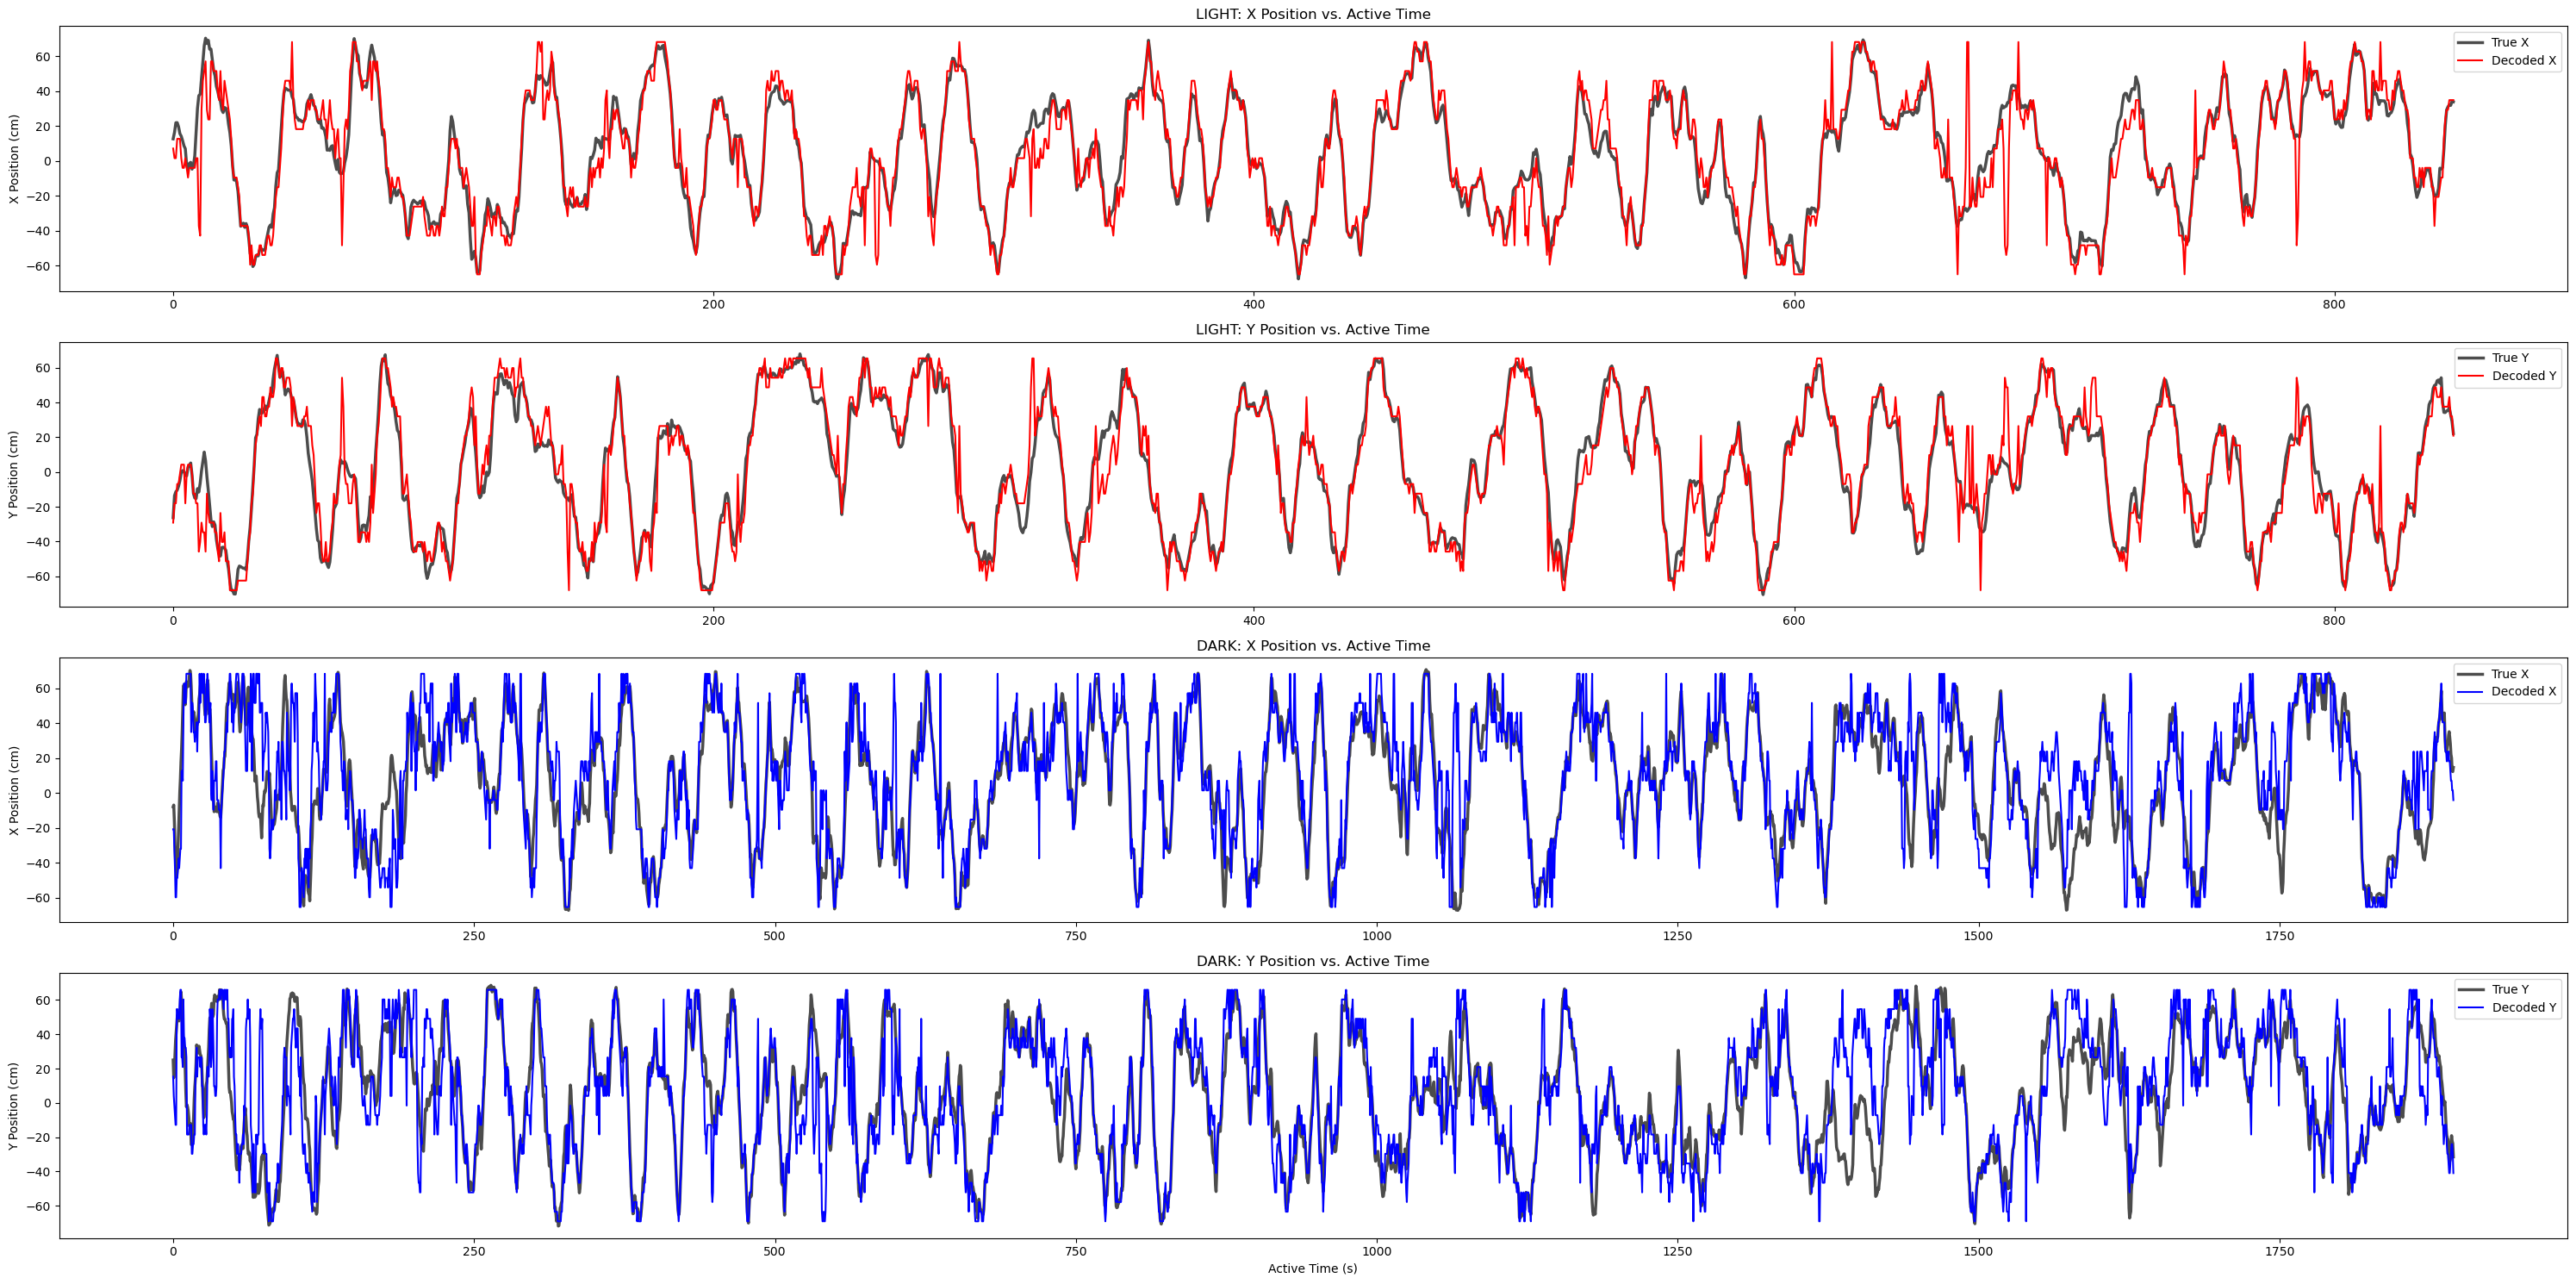

In [5]:
decoder_light = WholeSessionDecoder(
    RAT_ID=5, 
    LIGHTING='light', 
    sigma_pos=2.0,   # Gaussian smoothing sigma for position
    min_v=3.0,       # Minimum speed threshold (cm/s)
    max_v=100.0      # Maximum speed threshold (cm/s)
)

decoded_trajectory_with_prior_light = decoder_light.decode_whole_trajectory_with_prior(dt_decode=0.5)

decoder_dark = WholeSessionDecoder(
    RAT_ID=5, 
    LIGHTING='dark', 
    sigma_pos=2.0,   # Gaussian smoothing sigma for position
    min_v=3.0,       # Minimum speed threshold (cm/s)
    max_v=100.0      # Maximum speed threshold (cm/s)
)

decoded_trajectory_with_prior_dark = decoder_dark.decode_whole_trajectory_with_prior(dt_decode=0.5)
plot_light_dark_1d_gapless(decoded_trajectory_with_prior_light, decoded_trajectory_with_prior_dark, dt_decode=0.5)

# Animations

In [11]:
# Run
animate_7_panels_masked(decoder_dark, t1=2800, t2=3000, dt_decode=0.5 , save_path="./7_panel_masked_decoding.gif")

Decoding active session points...
Animation saved to ./7_panel_masked_decoding.gif


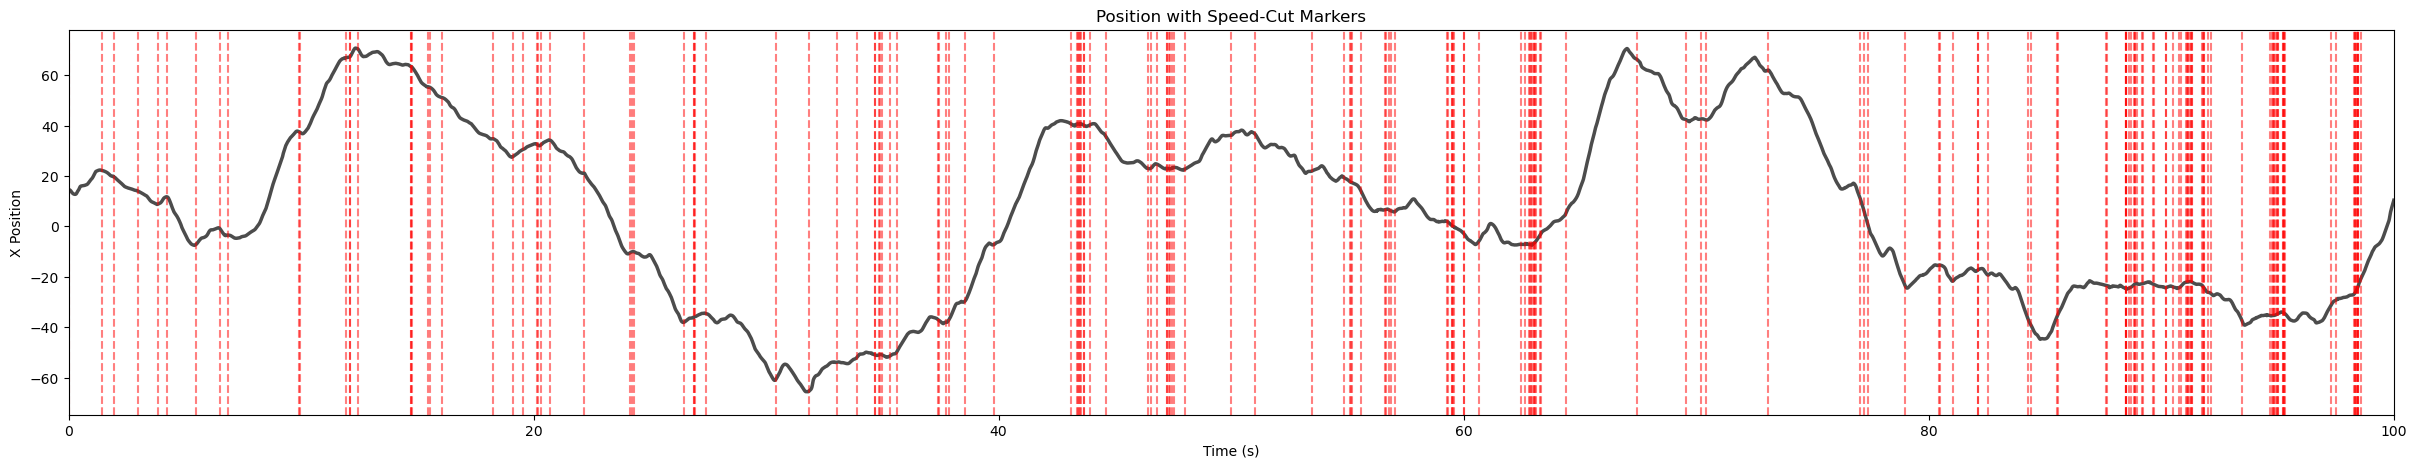

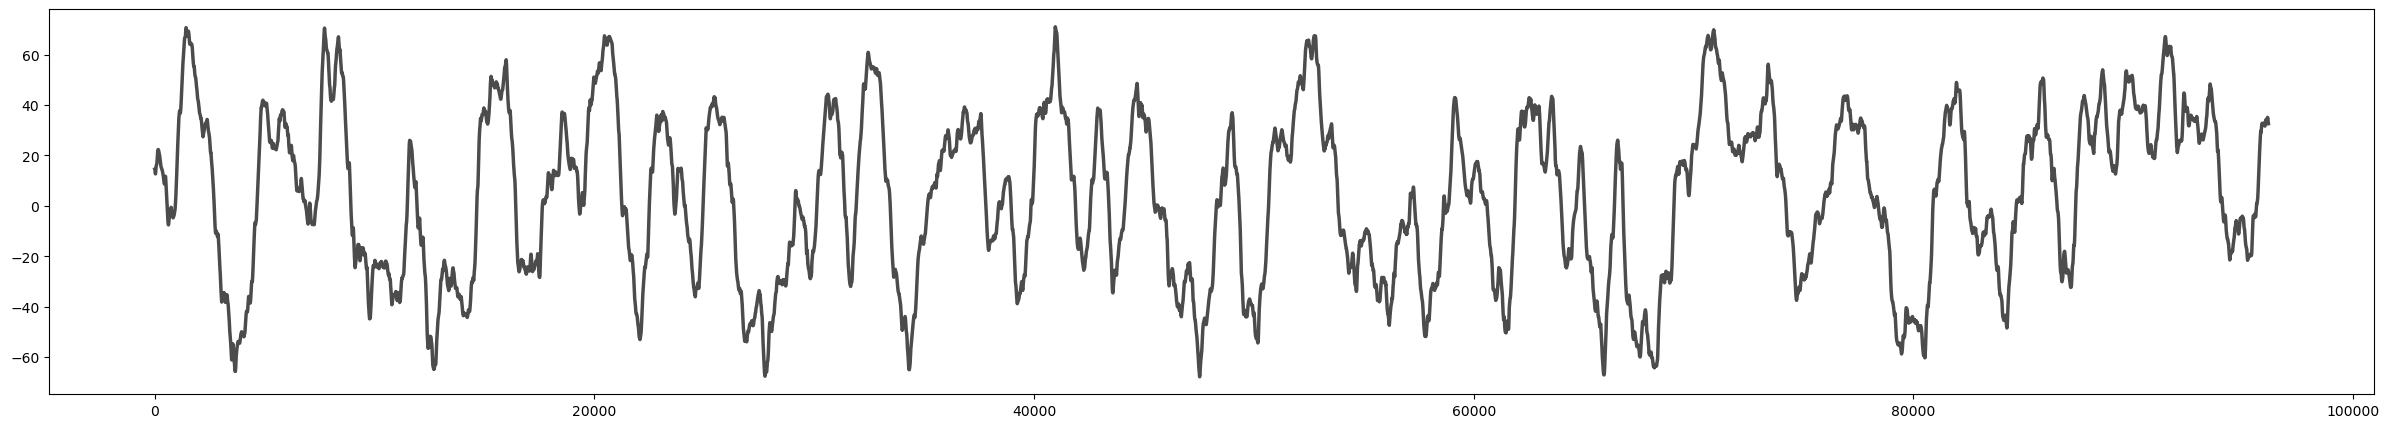

In [6]:
rat = RAT(n=5 , lighting='light' , filter_speed=True, min_v=3.0, max_v=100.0)

plt.figure(figsize=(30 , 5))
plt.plot(rat.t_active, rat.X, label='Filtered X position', color='black', linewidth=2.5, alpha=0.7)

# Add vertical lines at the start of every removed period
for t_start in rat.mapped_resume_times:
    plt.axvline(x=t_start, color='red', linestyle='--', alpha=0.5)

plt.xlim(0 , 100)
plt.xlabel('Time (s)')
plt.ylabel('X Position')
plt.title('Position with Speed-Cut Markers')
plt.show()


plt.figure(figsize=(30 , 5))
plt.plot(rat.X, label='Filtered X position', color='black', linewidth=2.5, alpha=0.7)

plt.show()

# rat = RAT(n=5 , lighting='light' , filter_speed=False, min_v=3.0, max_v=100.0)
# plt.figure(figsize=(30 , 5))

# plt.plot(rat.T , rat.X)

In [3]:
t_orig = rat.this_rat['t']
            
# Pad the mask with True at both ends to easily catch intervals 
# that start at frame 0 or end at the very last frame.
padded_mask = np.concatenate(([True], rat.valid_mask, [True]))
diffs = np.diff(padded_mask.astype(int))

# -1 means True -> False (Start of invalid interval)
invalid_starts = np.where(diffs == -1)[0]
# 1 means False -> True (End of invalid interval / Resume point)
invalid_ends = np.where(diffs == 1)[0]

# Safety catch: if the very last frame of the recording is invalid,
# clip the end index so we don't go out of bounds of t_orig
invalid_ends = np.clip(invalid_ends, 0, len(t_orig) - 1)

# 1. Get the original time (self.this_rat['t']) at the end of the interval
rat.end_times_orig = t_orig[invalid_ends]

# 2. Calculate the duration of each out-of-threshold interval
invalid_durations = t_orig[invalid_ends] - t_orig[invalid_starts]

In [5]:
invalid_durations 

array([0.71655173, 1.22496053, 5.08314832, ..., 0.13332381, 0.06664711,
       0.08346573])

In [8]:
rat = RAT(n=5 , lighting='light' , filter_speed=False, min_v=3.0, max_v=100.0)

x_smooth = gaussian_filter1d(rat.X, sigma=2)
y_smooth = gaussian_filter1d(rat.Y, sigma=2)
dx = np.gradient(x_smooth, rat.X)
dy = np.gradient(y_smooth, rat.Y)
dt = np.gradient(rat.X)
V = np.sqrt(dx**2 + dy**2) / dt

/Users/sara/miniconda3/envs/grid/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1307: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/Users/sara/miniconda3/envs/grid/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1307: RuntimeWarning: invalid value encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/Users/sara/miniconda3/envs/grid/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1308: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/sara/miniconda3/envs/grid/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1308: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/sara/miniconda3/envs/grid/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1309: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/sara/miniconda3/envs/grid/lib/python3.13/site-packages/numpy/li

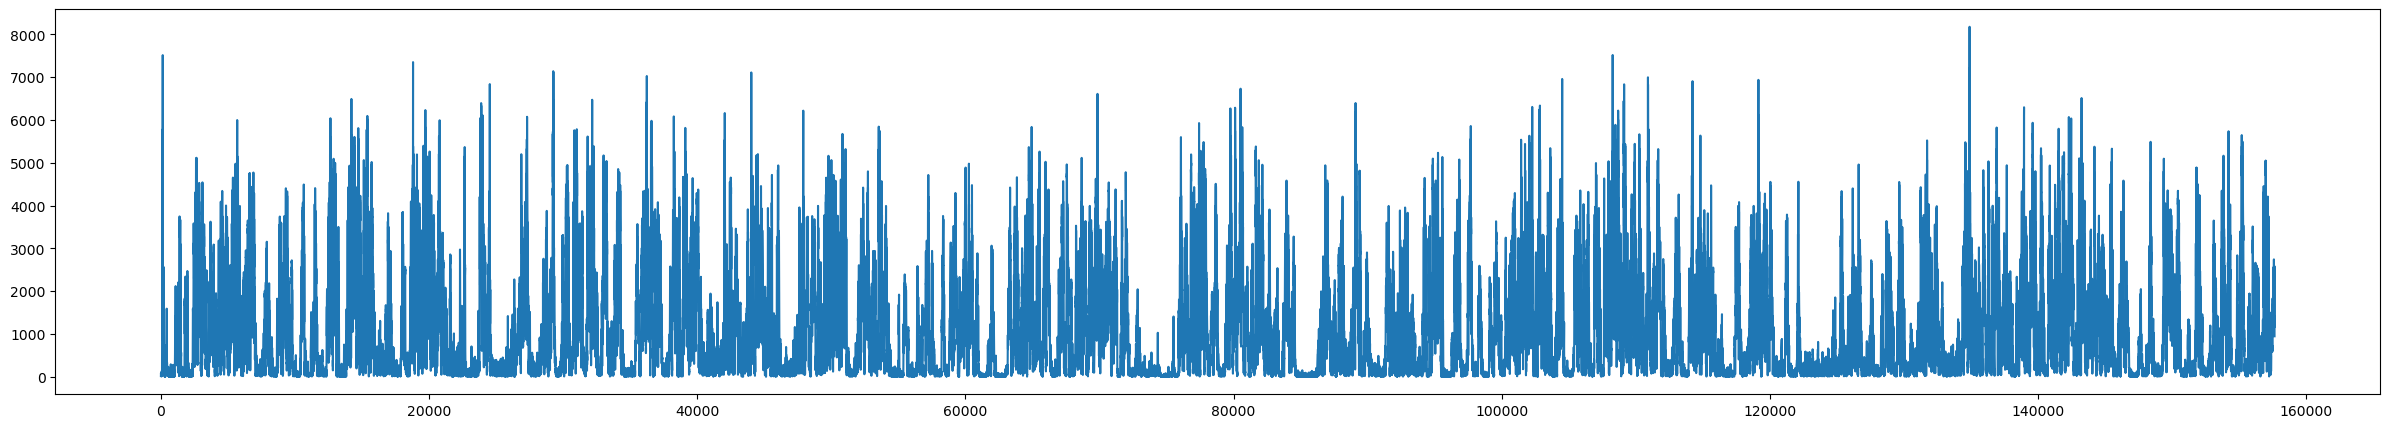

In [12]:
plt.figure(figsize=(30 , 5))

plt.plot(rat.V)

In [6]:
rat.t_active.shape, rat.X.shape , rat.T.shape

((28921,), (28921,), (28921,))

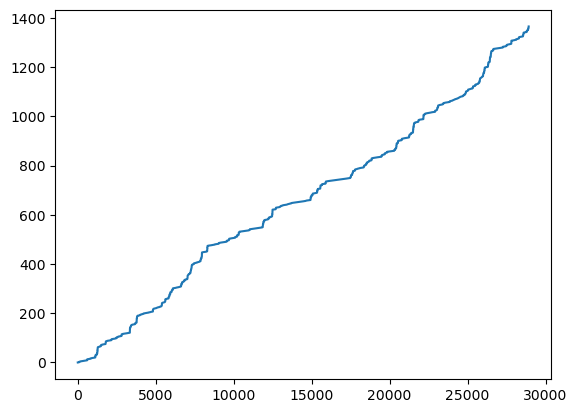

In [4]:
plt.plot(rat.T)

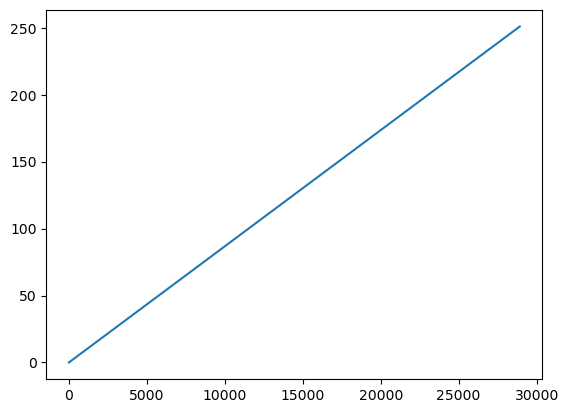

In [5]:
plt.plot(rat.t_active)

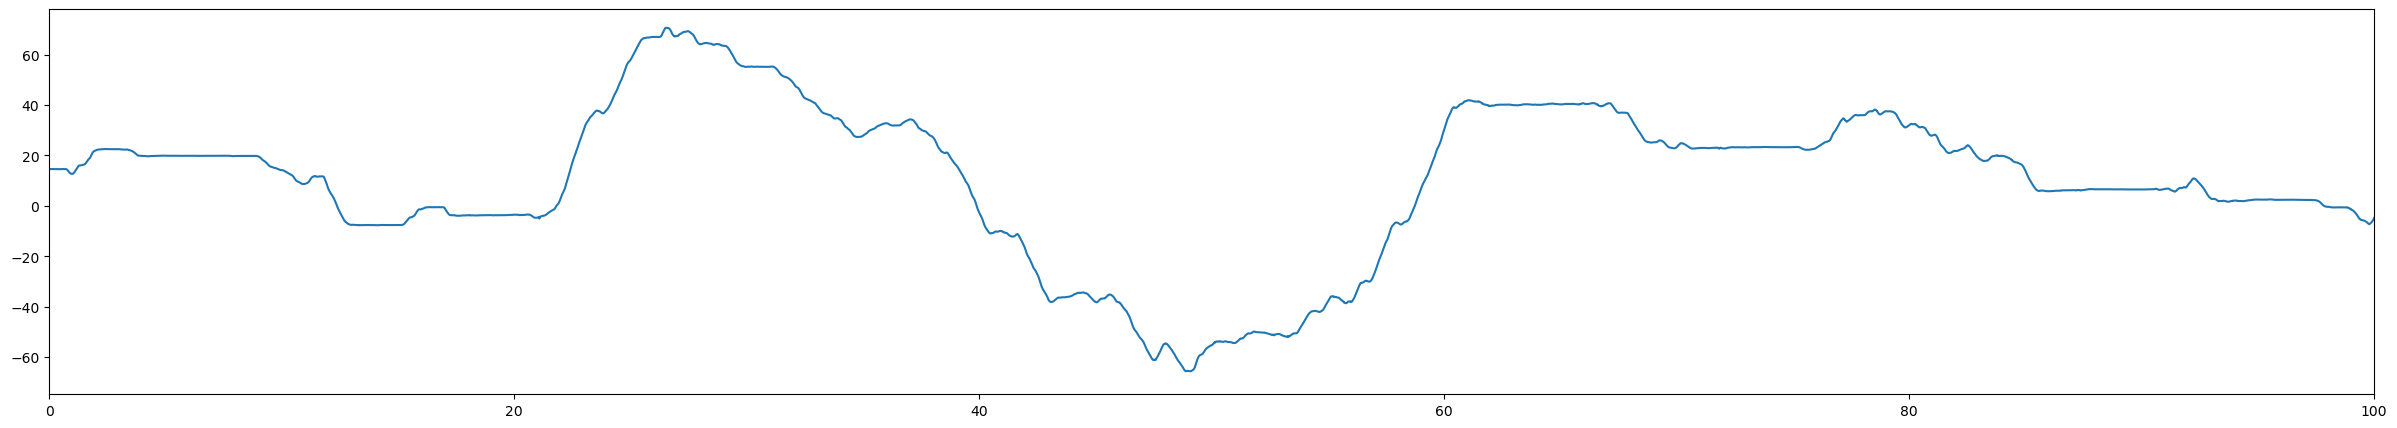

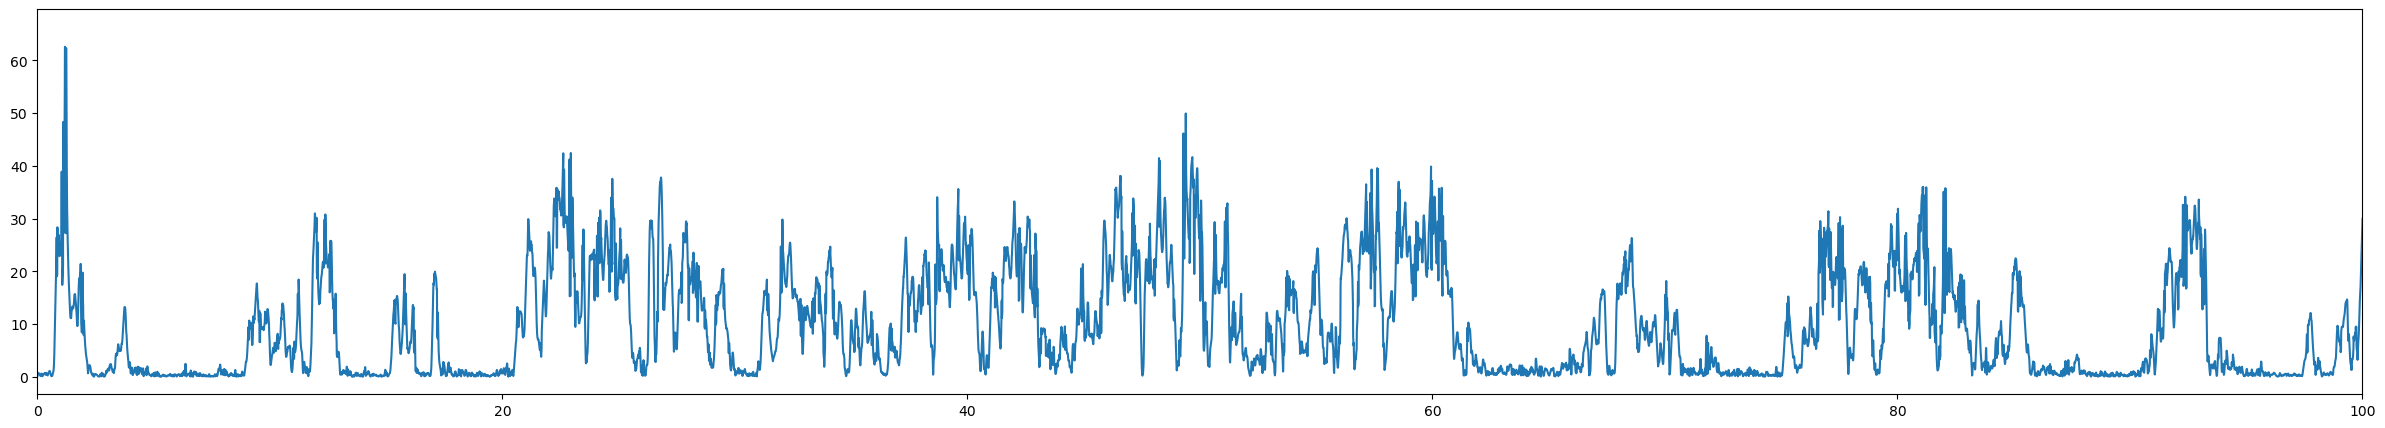

In [2]:
rat = RAT(n=5 , lighting='light' , filter_speed=False, min_v=3.0, max_v=100.0)
plt.figure(figsize=(30 , 5))

plt.plot(rat.T , rat.X)
plt.xlim(0 , 100)
plt.show()

plt.figure(figsize=(30 , 5))

plt.plot(rat.T , rat.V_full)
plt.xlim(0 , 100)
plt.show()